# S1 Backtest — ATR stop-loss bake-off (IS)

Set **`N_STAR`**, **`TIMING_STAR`**, **`WEIGHT_STAR`**, and (if `inv_vol`) **`INV_VOL_WINDOW_STAR`** by hand from notebooks 01–03.
On **research IS only**, grid **Wilder ATR** stop windows × multiples (+ no-stop baseline).

### Wilder ATR vs SMA of true range

True range is ``max(H-L, |H-prev_C|, |L-prev_C|)``. A simple mean of TR over ``n``
bars (SMA-TR) reacts sharply to one wide day. **Wilder ATR** uses the recursive
smoother ``ATR_t = (ATR_{t-1}*(n-1) + TR_t) / n`` (seeded with the SMA of the
first ``n`` TRs). That persistence is the market convention for stop/chandelier
levels and is less whippy — better for stop distances. Math lives in
`data.processing.feature_implementation.atr` (PIT ``shift(1)`` before entry open).

### Per-name stops

- Long stop = ``O_entry - k * ATR*``; short = ``O_entry + k * ATR*``.
- Daily high/low path; gap-aware fill; liquidate that name **once** (no re-exit).
- Active over the full hold, including the weekend / Mon open gap.

### Costs (Alpaca-representative)

| Event | One-way |
|---|---|
| Monday open entry / roll | **15.5 bps** (open) |
| Early stop liquidation | **10.5 bps** (close / regular session) |
| Friday scheduled flatten | **10.5 bps** (close) |
| Names already stopped are zeroed so Monday does **not** double-charge their exit |

Pick **`STOP_STAR`** by **IS net Sharpe**. Copy into `08_oos_tearsheet`. No CSV writes.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.portfolio import (
    WEIGHT_EQUAL,
    WEIGHT_INV_VOL,
    WEIGHT_RANK,
    WEIGHT_SCORE,
)
from backtest.s1_equities.report import plot_equity_overlay
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_FRI_CLOSE,
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)
from backtest.s1_equities.stops import STOP_NONE, StopConfig
from data.processing.feature_implementation.atr import DEFAULT_ATR_WINDOW
from data.processing.feature_implementation.realized_vol import DEFAULT_OPEN_VOL_WINDOW

PATHS = default_backtest_paths(ROOT)

# --- Set from notebooks 01 / 02 / 03 ---
N_STAR = 15
TIMING_STAR = TIMING_MON_OPEN_MON_OPEN  # or TIMING_MON_OPEN_FRI_CLOSE
WEIGHT_STAR = WEIGHT_INV_VOL  # or WEIGHT_EQUAL / WEIGHT_SCORE / WEIGHT_RANK
# From notebook 03 §5 when WEIGHT_STAR is inv_vol (ignored otherwise)
INV_VOL_WINDOW_STAR = 42

ATR_WINDOWS = [5, 7, 14, 21]
ATR_MULTIPLES = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
PRED_PATH = prediction_path_for_timing(PATHS, TIMING_STAR)

print(f"N_STAR={N_STAR}  TIMING_STAR={TIMING_STAR}  WEIGHT_STAR={WEIGHT_STAR}")
print(f"INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR} (used when WEIGHT_STAR=inv_vol)")
print(f"predictions={PRED_PATH}")
print(f"ATR default ref window={DEFAULT_ATR_WINDOW}; grid windows={ATR_WINDOWS}")
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15  TIMING_STAR=mon_open_mon_open  WEIGHT_STAR=inv_vol
INV_VOL_WINDOW_STAR=42 (used when WEIGHT_STAR=inv_vol)
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet
ATR default ref window=14; grid windows=[5, 7, 14, 21]


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Daily OHLC (explicit)

Stops use **daily** `high` / `low` from the engineered S1 feature panel parquet
(`PATHS["features"]`), loaded via `load_ohlc_panels` (columns
`date, ticker, open, high, low, close` → wide pivots).


In [2]:
feats_path = PATHS["features"]
print(f"features parquet: {feats_path}")
print(f"exists={os.path.isfile(feats_path)}")

preds = load_predictions(PRED_PATH)
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)

opens, highs, lows, closes = load_ohlc_panels(
    feats_path, tickers=list(scores.columns)
)
print(
    f"opens={opens.shape} highs={highs.shape} lows={lows.shape} closes={closes.shape}"
)
print(f"IS entry dates={int(is_mask.sum())}")
display(highs.head(3))
display(lows.head(3))


features parquet: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet
exists=True
opens=(4165, 68) highs=(4165, 68) lows=(4165, 68) closes=(4165, 68)
IS entry dates=411


ticker,AAPL,ABT,ADBE,AMAT,AMD,AMGN,AMZN,BA,BAX,BBY,...,PM,QCOM,RRC,SBUX,SLB,TGT,TXN,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,6.421146,18.111994,37.299999,11.207418,9.90,38.849243,6.8305,43.941189,23.380160,23.332521,...,23.056263,31.296249,48.420293,8.605327,45.351634,30.864642,17.329474,24.322957,13.160060,13.013926
2010-01-06,6.453779,18.082116,37.799999,11.061268,9.90,38.728410,6.7740,45.413942,23.110649,23.861503,...,23.046959,31.964361,49.091264,8.852460,45.635081,31.079299,17.127588,24.607752,13.140382,12.899667
2010-01-07,6.443003,18.055566,37.740002,11.076655,9.76,38.527032,6.7365,46.746436,23.142357,23.769507,...,22.781945,32.037125,49.238326,8.712302,46.525928,31.376009,16.951753,24.677031,13.066893,12.813969


ticker,AAPL,ABT,ADBE,AMAT,AMD,AMGN,AMZN,BA,BAX,BBY,...,PM,QCOM,RRC,SBUX,SLB,TGT,TXN,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,6.357683,17.899535,36.650002,10.792043,9.68,37.969816,6.6570,42.702201,22.845098,22.786293,...,22.433247,30.806727,46.931287,8.450409,44.622772,30.555303,16.860581,23.838037,13.018427,12.775881
2010-01-06,6.383729,17.843100,36.869999,10.799736,9.68,37.775138,6.5905,43.637282,22.872844,23.286527,...,22.670359,31.421920,48.116974,8.443034,45.034442,30.466930,16.736845,24.076651,12.896459,12.752078
2010-01-07,6.308892,17.876306,37.200001,10.845892,9.55,37.929558,6.5825,45.102245,22.880773,23.378523,...,22.451840,31.342536,48.429482,8.579514,45.236913,30.675256,16.645669,24.176716,12.691729,12.716372


## 2. IS stop grid


In [3]:
configs = [StopConfig(mode=STOP_NONE)]
for w in ATR_WINDOWS:
    for k in ATR_MULTIPLES:
        configs.append(StopConfig(mode="atr", atr_window=w, atr_multiple=k))

results = {}
rows = []
for cfg in configs:
    res = run_backtest(
        scores,
        opens,
        closes,
        n=N_STAR,
        timing_mode=TIMING_STAR,
        weight_mode=WEIGHT_STAR,
        inv_vol_window=INV_VOL_WINDOW_STAR,
        costs=DEFAULT_COSTS,
        date_mask=is_mask,
        highs=highs,
        lows=lows,
        stop=cfg,
    )
    label = cfg.label()
    results[label] = res
    sm = summarize_periods(res.period_returns)
    rows.append(
        {
            "stop": label,
            "atr_window": cfg.atr_window,
            "atr_multiple": cfg.atr_multiple,
            "sharpe": sm["sharpe"],
            "cagr": sm["cagr"],
            "total_return": sm["total_return"],
            "max_drawdown": sm["max_drawdown"],
            "vol": sm["vol"],
            "win_rate": sm["win_rate"],
            "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
            "n_periods": sm["n_periods"],
            "stop_hit_rate": res.stop_hit_rate,
            "mean_names_stopped": res.mean_names_stopped,
            "mean_early_exit_notional": res.mean_early_exit_notional,
        }
    )
    print(
        f"{label}: sharpe={sm['sharpe']:.3f}  dd={sm['max_drawdown']:.3%}  "
        f"hit={res.stop_hit_rate:.3f}  turn={res.turnover.mean():.3f}"
    )

bake_df = pd.DataFrame(rows).set_index("stop")
display(bake_df.sort_values("sharpe", ascending=False))

best = bake_df["sharpe"].idxmax()
STOP_STAR = str(best)
print(f"Suggested STOP_STAR={STOP_STAR}  (IS net Sharpe={bake_df.loc[STOP_STAR, 'sharpe']:.4f})")
print("Copy this string into STOP_STAR in notebook 08.")


none: sharpe=0.938  dd=-20.990%  hit=0.000  turn=0.169
atr_5_1: sharpe=-1.328  dd=-56.204%  hit=0.431  turn=0.745
atr_5_1.5: sharpe=-0.474  dd=-27.832%  hit=0.263  turn=0.518
atr_5_2: sharpe=0.130  dd=-24.700%  hit=0.158  turn=0.377
atr_5_2.5: sharpe=0.408  dd=-22.909%  hit=0.095  turn=0.294
atr_5_3: sharpe=0.547  dd=-23.271%  hit=0.059  turn=0.246
atr_5_3.5: sharpe=0.709  dd=-22.486%  hit=0.035  turn=0.215
atr_5_4: sharpe=0.774  dd=-21.710%  hit=0.024  turn=0.199
atr_7_1: sharpe=-1.327  dd=-56.770%  hit=0.431  turn=0.744
atr_7_1.5: sharpe=-0.457  dd=-27.832%  hit=0.260  turn=0.514
atr_7_2: sharpe=0.130  dd=-23.988%  hit=0.155  turn=0.374
atr_7_2.5: sharpe=0.390  dd=-23.785%  hit=0.093  turn=0.291
atr_7_3: sharpe=0.518  dd=-23.434%  hit=0.057  turn=0.244
atr_7_3.5: sharpe=0.669  dd=-22.503%  hit=0.035  turn=0.214
atr_7_4: sharpe=0.753  dd=-21.666%  hit=0.023  turn=0.198
atr_14_1: sharpe=-1.363  dd=-57.868%  hit=0.431  turn=0.744
atr_14_1.5: sharpe=-0.420  dd=-26.531%  hit=0.257  turn=0

,atr_window,atr_multiple,sharpe,cagr,total_return,max_drawdown,vol,win_rate,mean_turnover,n_periods,stop_hit_rate,mean_names_stopped,mean_early_exit_notional
stop,,,,,,,,,,,,,
none,NaN,NaN,0.938172,0.073793,0.753056,-0.209901,0.079294,0.602439,0.169383,410,0.000000,0.000000,0.000000
atr_5_4,5.0,4.0,0.774185,0.059646,0.579009,-0.217104,0.078901,0.595122,0.198834,410,0.023902,0.717073,0.024623
atr_7_4,7.0,4.0,0.753360,0.058221,0.562341,-0.216660,0.079341,0.595122,0.197864,410,0.023008,0.690244,0.023833
atr_14_4,14.0,4.0,0.714696,0.055177,0.527254,-0.216123,0.079632,0.592683,0.197069,410,0.022520,0.675610,0.023668
atr_5_3.5,5.0,3.5,0.709323,0.054724,0.522091,-0.224858,0.079627,0.590244,0.214678,410,0.035366,1.060976,0.036826
atr_21_4,21.0,4.0,0.692895,0.053660,0.510031,-0.219437,0.080116,0.590244,0.197303,410,0.023089,0.692683,0.023904
atr_7_3.5,7.0,3.5,0.668661,0.051674,0.487732,-0.225034,0.080205,0.587805,0.214239,410,0.035203,1.056098,0.036652
atr_14_3.5,14.0,3.5,0.647100,0.050109,0.470369,-0.224094,0.080627,0.590244,0.212364,410,0.034472,1.034146,0.035597
atr_21_3.5,21.0,3.5,0.612989,0.047243,0.439017,-0.223651,0.080655,0.582927,0.212919,410,0.035122,1.053659,0.036413


Suggested STOP_STAR=none  (IS net Sharpe=0.9382)
Copy this string into STOP_STAR in notebook 07.


## 3. Heatmap & equity overlay


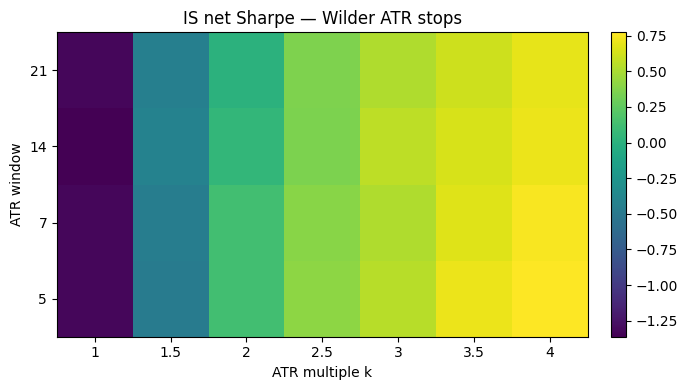

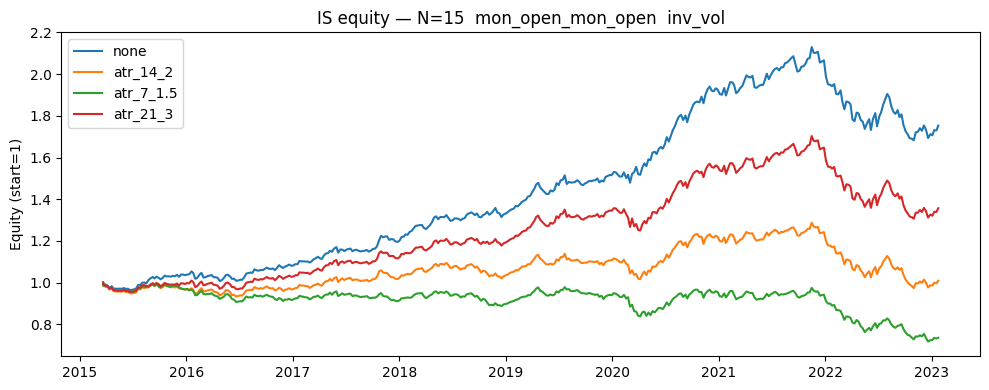

In [4]:
atr_only = bake_df.dropna(subset=["atr_window"]).copy()
heat = atr_only.pivot_table(
    index="atr_window", columns="atr_multiple", values="sharpe"
)
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heat.to_numpy(dtype=float), aspect="auto", origin="lower")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"{c:g}" for c in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([str(int(i)) for i in heat.index])
ax.set_xlabel("ATR multiple k")
ax.set_ylabel("ATR window")
ax.set_title("IS net Sharpe — Wilder ATR stops")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Overlay: none, best, and a couple of mid-grid representatives
overlay_keys = [STOP_NONE, STOP_STAR]
for cand in ("atr_14_2", "atr_7_1.5", "atr_21_3"):
    if cand in results and cand not in overlay_keys:
        overlay_keys.append(cand)
fig = plot_equity_overlay(
    {k: results[k].equity for k in overlay_keys if k in results},
    title=f"IS equity — N={N_STAR}  {TIMING_STAR}  {WEIGHT_STAR}",
)
plt.show()


## 4. Suggested STOP_STAR


In [5]:
print(
    f"Suggested STOP_STAR={STOP_STAR} — set STOP_STAR={STOP_STAR!r} in 08_oos_tearsheet"
)
display(bake_df.loc[[STOP_STAR]].T)


Suggested STOP_STAR=none — set STOP_STAR='none' in 07_oos_tearsheet


stop,none
atr_window,NaN
atr_multiple,NaN
sharpe,0.938172
cagr,0.073793
total_return,0.753056
max_drawdown,-0.209901
vol,0.079294
win_rate,0.602439
mean_turnover,0.169383
n_periods,410.000000
